Bibliotekos:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#### Pagrindinių komponentų analizė:

Pagrindinių komponenčių analizei pritaikyti naudojamas *sklearn* paketas, kuriame jau yra realizuotas pagrindinių komponenčių analizės algoritmas. Tereikia iškviesti *PCA* funkciją ir nurodyti norimus hiperparametrus. 

Prieš pereinant prie hiperparametrų, trumpai reiktų pristatyti duomenų reikalavimus ir funkcijas naudojamas kartu su *PCA* algoritmu. Sukūrus *PCA* algoritmo objektą, pirmiausia reiktų naudoti funkciją *fit*, kuriai pateikiama standartizuota duomenų aibė, ši funkcija atlieka visus matematinius skaičiavimus aptartus teorijoje, apskaičiuoja pagrindes komponentes ir jų paaiškinamą dispersiją (*explained_variance_ratio_*), pati duomenų aibės struktūra šiame etape nekeičiama. Ji mažinama naudojant *transform* funkciją, kuri ir taiko dimensijų mažinimą, pradinės duomenų aibės stebėjimus projektuoja į mažesnę dimensiją naudojant jau apskaičiuotas pagrindines komponentes. Galima apjungti abi šias funkcijas ir taikyti funkciją *fit_transform*, kuri atlieka abu žingsnius vienu kartu.

Pereinant prie funkcijos pasileidimo ir pritaikymo, algoritmas veikia ir nenurodant jokių hiperparametrų - tokiu atveju apskaičiuojama tiek pagrindinių komponenčių kiek duomenyse yra nagrinėjamų požymių. Iškviečiant *PCA* funkciją ir jos viduje pateikiant skaičių lygu $0.95$, tai reikštų, kad algoritmas skaičiuos ir naudojant *PCA* funkcijos derinį *explained_variance_ratio_* grąžins tiek komponenčių, kad sudėjus visų komponenčių paaiškinimą dispersiją, gautųsi jog paaiškinama 95 % visos bendros dispersijos.

Naudojant *PCA* funkcijos *n_components* hiperparametrą galima nurodyti, kiek komponenčių norime gauti ir tos komponentės vėliau bus naudojamos duomenų aibės transformacijai. 

Pereinant prie kito *PCA* hiperparametro *whiten=True*, kuris paima *components_* vektorių, kuriame saugoma kiekvienos komponetės sudėtis, kiek kiekvienas požymis prisidėjo, padaugina iš imties dydžio kvadratinės šaknies ir padalina iš tikrinių reikšmių. Taip užtikrindamas, kad gautos išvestys bus nekoreliuotos, o kiekvienos komponentės dispersija bus lygi vienetui. Nors tai gali pagerinti vėlesnių mašininio mokymosi modelių tikslumą, taikant šį metodą prarandama dalis informacijos, kadangi komponenčių svoriai suvienodinami.

In [2]:
def PCA_Algorithm1 (data_scaled):
    pca = PCA(0.95)
    data_pca = pca.fit_transform(data_scaled)
    return (data_pca, pca.explained_variance_ratio_)

In [3]:
def PCA_Algorithm2 (data_scaled, n_comp):
    pca = PCA(n_components = n_comp)
    data_pca = pca.fit_transform(data_scaled)
    return (data_pca, pca.explained_variance_ratio_)

In [4]:
def PCA_Algorithm3 (data_scaled):
    pca = PCA(whiten = True)
    data_pca = pca.fit_transform(data_scaled)
    return (data_pca, pca.explained_variance_ratio_)

Toliau pereikime prie hiperparametro *svd_solver*, kuriame galima nurodyti vieną iš penkių pasirinkimų, kuris bus naudojamas matematiniams skaičiavimams:
- *'auto'*:

    Tai yra numatytasis pasirinkimas veikiantis pagal taisyklę, kuris parenka sprendimą iš likusių keturių pagal duomenų struktūrą ir komponenčių skaičių:
    - Jei įvesties duomenyse yra mažiau nei 1000 požymių, o stebėjimų yra bent 10 kartų daugiau - naudojamas *'covariance_eigh'*;
    - Jei įvesties duomenys yra didesni nei 500 $\times$ 500 ir norimas išskirti komponenčių skaičius yra mažesnis nei 80 % mažiausio duomenų matmens - *'randomized'*;
    - Visais kitais atvejais skaičiuojama tiksli „full“ SVD.

- 'full' - apskaičiuoja visas vienetines reikšmes ir vektorius, net jei vartotojui prireikia tik kelių komponenčių;
- 'covariance_eigh' - tikrinės reikšmės ir tikriniai vektoriai ieškomi apskaičiuojant kovariacijų matricą;
- 'arpack' - vietoje ieškant visų, ieškoma tiek kovariančių, kiek paprašė vartotojas;
- 'randomized' - naudojamos atsitiktinės projekcijos, kad rastų apytikslę duomenų struktūrą, naudojama, kad duomenys yra dideli ir nepakanka resursų apskaičiuoti tikslias reikšmes.


In [5]:
def pca_solvers(data):
    solvers = ['auto', 'full', 'covariance_eigh', 'arpack', 'randomized']
    names = []
    results = []

    for s in solvers:
        start_time = time.time()
        pca = PCA(svd_solver = s)
        pca.fit(data)
        end_time = time.time()
        names.append(s)
        results.append(end_time - start_time)

    return pd.DataFrame({"solver": names, "time (s)": results})

#### Pirmas duomenų rinkinys:

In [6]:
df_ellipsoid = pd.read_csv("ellipsoid.50d10c.8.txt", sep = '\t', header = None)
df_ellipsoid.head(5)

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,-0.006412,0.002997,-0.028828,-0.005403,0.070193,0.055493,-0.067224,-0.042464,0.040229,-0.027893,...,0.031264,0.051459,0.033878,0.050101,0.035105,-0.123535,-0.019261,0.052944,-0.070087,0.006853
1,0.101276,0.049836,0.058219,0.057525,0.052512,0.091341,-0.137052,0.034034,0.047139,-0.122298,...,0.027550,0.050529,0.110795,0.020408,-0.035099,-0.212835,0.001148,0.194039,-0.012406,0.027588
2,-0.025276,-0.024517,-0.058769,-0.007441,0.055704,0.048386,-0.026769,-0.059224,0.019099,0.020766,...,-0.018689,0.064856,0.028137,0.042149,0.060543,-0.085773,-0.024084,0.039798,-0.042798,-0.010927
3,0.087410,0.049991,0.050905,0.043360,0.051087,0.056953,-0.138113,0.020437,0.050432,-0.119749,...,0.029750,0.052365,0.092220,0.003401,0.003823,-0.201655,-0.026034,0.197960,-0.033710,0.001458
4,0.160108,0.064853,0.103496,0.080948,0.057654,0.114975,-0.193117,0.074163,0.066625,-0.203372,...,0.046991,0.037344,0.170901,0.009572,-0.071378,-0.276137,0.001418,0.267204,-0.022505,0.046585


In [7]:
print("Duomenų struktūra: ", df_ellipsoid.shape)

Duomenų struktūra:  (3140, 50)


In [8]:
sc = StandardScaler()
ellipsoid_scaled = sc.fit_transform(df_ellipsoid)
transformed_ellipsoid1, variance_ellipsoid1 = PCA_Algorithm1(ellipsoid_scaled)
variance_ellipsoid1_proc = np.round(variance_ellipsoid1 * 100, decimals = 1)

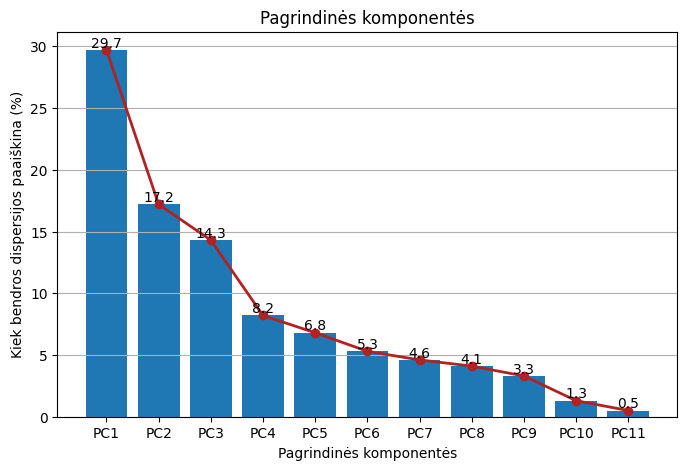

In [9]:
# var_pca_ellipsoid_10 = var_pca_ellipsoid1[:10]
labels = ["PC" + str(x) for x in range(1, len(variance_ellipsoid1_proc) + 1)]

plt.figure(figsize = (8, 5))
plt.grid(axis = 'y')
bars = plt.bar(x = range(1, len(variance_ellipsoid1_proc) + 1), height = variance_ellipsoid1_proc, tick_label = labels)
plt.plot(range(1, len(variance_ellipsoid1_proc) + 1), variance_ellipsoid1_proc, marker = 'o', color='firebrick', linewidth = 2, markersize = 6)
plt.bar_label(bars)
plt.title("Pagrindinės komponentės")
plt.ylabel("Kiek bendros dispersijos paaiškina (%)")
plt.xlabel("Pagrindinės komponentės")
plt.show()

In [10]:
transformed_ellipsoid3, variance_ellipsoid3 = PCA_Algorithm3(ellipsoid_scaled)
variance_ellipsoid3_proc = np.round(variance_ellipsoid3 * 100, decimals = 1)

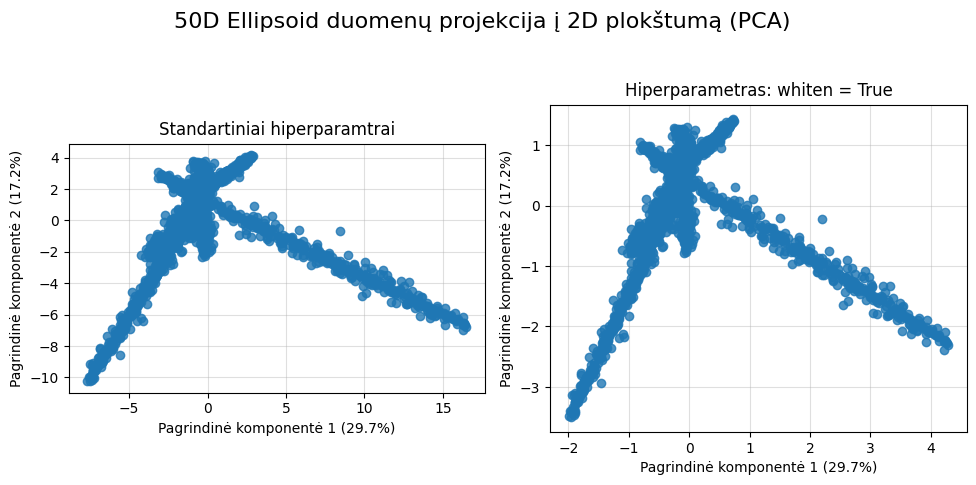

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.scatter(transformed_ellipsoid1[:, 0], transformed_ellipsoid1[:, 1], alpha=0.8)
ax1.set_title("Standartiniai hiperparamtrai")
ax1.set_xlabel(f"Pagrindinė komponentė 1 ({variance_ellipsoid1_proc[0]}%)")
ax1.set_ylabel(f"Pagrindinė komponentė 2 ({variance_ellipsoid1_proc[1]}%)")
ax1.grid(alpha=0.4)
ax1.set_aspect('equal', adjustable='box')
ax1.set_axisbelow(True)

ax2.scatter(transformed_ellipsoid3[:, 0], transformed_ellipsoid3[:, 1], alpha=0.8)
ax2.set_title("Hiperparametras: whiten = True")
ax2.set_xlabel(f"Pagrindinė komponentė 1 ({variance_ellipsoid3_proc[0]}%)")
ax2.set_ylabel(f"Pagrindinė komponentė 2 ({variance_ellipsoid3_proc[1]}%)")
ax2.grid(alpha=0.4)
ax2.set_aspect('equal', adjustable='box')
ax2.set_axisbelow(True)

plt.suptitle("50D Ellipsoid duomenų projekcija į 2D plokštumą (PCA)", fontsize=16)
plt.tight_layout()
plt.show()

In [12]:
print("Pirmos komponentės dispersija (be whitening):", np.var(transformed_ellipsoid1[:,0]))
print("Pirmos komponentės dispersija (whiten=True):", np.var(transformed_ellipsoid3[:,0]))

Pirmos komponentės dispersija (be whitening): 14.852430461844996
Pirmos komponentės dispersija (whiten=True): 0.9996815286624219


In [13]:
pca_solvers(ellipsoid_scaled)

,solver,time (s)
0,auto,0.003620
1,full,0.029159
2,covariance_eigh,0.002072
3,arpack,0.065812
4,randomized,0.050780


-----

#### Antras duomenų rinkinys:

In [14]:
df_iris = pd.read_csv("iris_with_class.txt", sep = '\t', header = None)
df_iris.head(5)

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [15]:
y_iris = df_iris[4]
df_iris = df_iris.drop(4, axis=1)
df_iris.head(5)

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [16]:
print("Duomenų struktūra: ", df_iris.shape)

Duomenų struktūra:  (150, 4)


In [17]:
iris_scaled = sc.fit_transform(df_iris)
transformed_iris2, variance_iris2 = PCA_Algorithm2(iris_scaled, 4)
variance_iris2_proc = np.round(variance_iris2 * 100, decimals = 1)

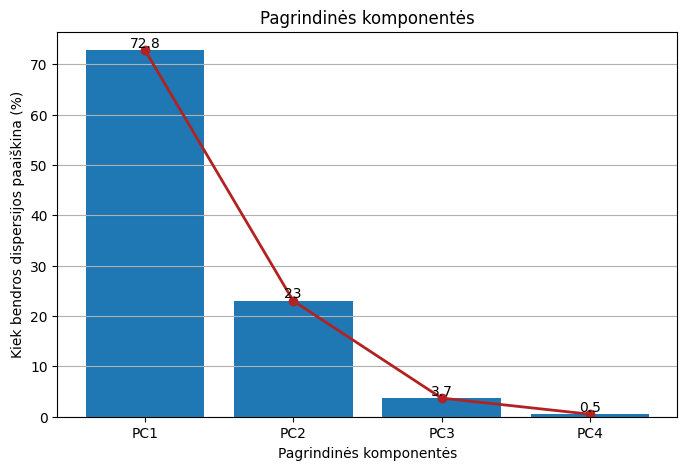

In [18]:
labels = ["PC" + str(x) for x in range(1, len(variance_iris2_proc) + 1)]

plt.figure(figsize = (8, 5))
plt.grid(axis = 'y')
bars = plt.bar(x = range(1, len(variance_iris2_proc) + 1), height = variance_iris2_proc, tick_label = labels)
plt.bar_label(bars)
plt.plot(range(1, len(variance_iris2_proc) + 1), variance_iris2_proc, marker = 'o', color='firebrick', linewidth = 2, markersize = 6)
plt.title("Pagrindinės komponentės")
plt.ylabel("Kiek bendros dispersijos paaiškina (%)")
plt.xlabel("Pagrindinės komponentės")
plt.show()

In [19]:
transformed_iris3, variance_iris3 = PCA_Algorithm3(iris_scaled)
variance_iris3_proc = np.round(variance_iris3 * 100, decimals = 1)

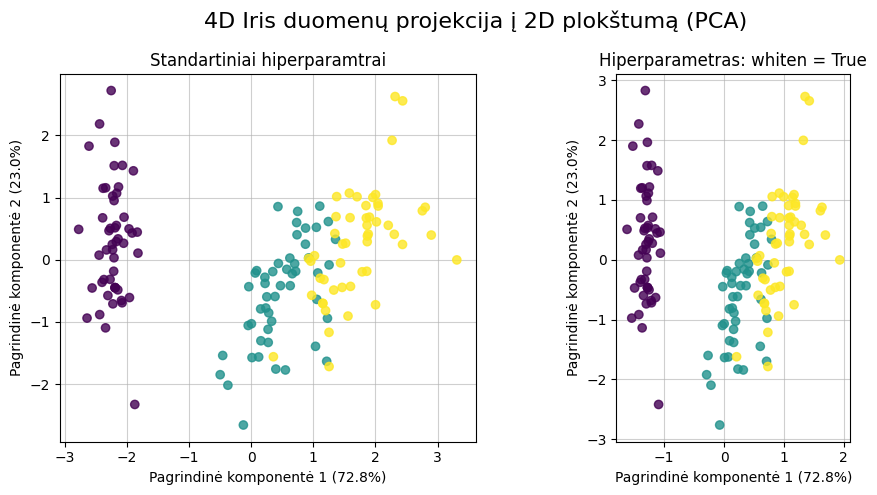

In [20]:
y_numeric = pd.factorize(y_iris)[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.scatter(transformed_iris2[:, 0], transformed_iris2[:, 1], alpha=0.8, c = y_numeric)
ax1.set_title("Standartiniai hiperparamtrai")
ax1.set_xlabel(f"Pagrindinė komponentė 1 ({variance_iris2_proc[0]}%)")
ax1.set_ylabel(f"Pagrindinė komponentė 2 ({variance_iris2_proc[1]}%)")
ax1.grid(alpha=0.6)
ax1.set_aspect('equal', adjustable='box')
ax1.set_axisbelow(True)

ax2.scatter(transformed_iris3[:, 0], transformed_iris3[:, 1], alpha=0.8, c = y_numeric)
ax2.set_title("Hiperparametras: whiten = True")
ax2.set_xlabel(f"Pagrindinė komponentė 1 ({variance_iris3_proc[0]}%)")
ax2.set_ylabel(f"Pagrindinė komponentė 2 ({variance_iris3_proc[1]}%)")
ax2.grid(alpha=0.6)
ax2.set_aspect('equal', adjustable='box')
ax2.set_axisbelow(True)

plt.suptitle("4D Iris duomenų projekcija į 2D plokštumą (PCA)", fontsize=16)
plt.tight_layout()
plt.show()

In [21]:
pca_solvers(iris_scaled)

,solver,time (s)
0,auto,0.001015
1,full,0.001124
2,covariance_eigh,0.001016
3,arpack,0.002645
4,randomized,0.002578


In [22]:
pca = PCA()
data_pca = pca.fit_transform(iris_scaled)

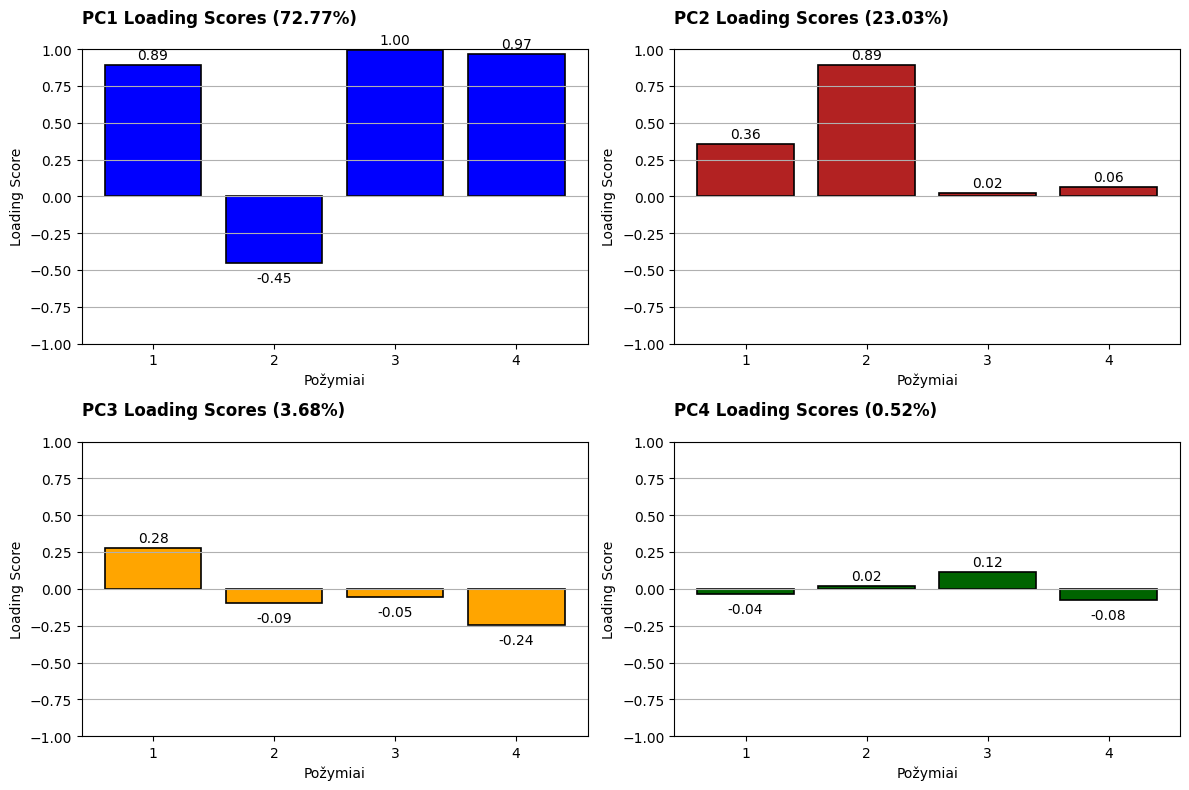

In [23]:
loadings = pd.DataFrame(
    data = pca.components_.T * np.sqrt(pca.explained_variance_), 
    columns = [f"PC{i}" for i in range(1, len(df_iris.columns) + 1)],
    index = [f"{i}" for i in range(1, len(df_iris.columns) + 1)]
)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
colors = ["blue", "firebrick", "orange", "darkgreen"]

for i, ax in enumerate(axs.flatten()):
    explained_variance = pca.explained_variance_ratio_[i] * 100
    pc = f"PC{i+1}"
    bars = ax.bar(loadings.index, loadings[pc], color=colors[i], edgecolor="black", linewidth=1.2)
    ax.set_title(f"{pc} Loading Scores ({explained_variance:.2f}%)", loc="left", fontdict={"weight": "bold"}, y=1.06)
    ax.set_xlabel("Požymiai")
    ax.set_ylabel("Loading Score")
    ax.grid(axis="y")
    ax.tick_params(axis="x")
    ax.set_ylim(-1, 1)

    for bar in bars:
        yval = bar.get_height()
        offset = yval + 0.02 if yval > 0 else yval - 0.15
        ax.text(bar.get_x() + bar.get_width() / 2, offset, f"{yval:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

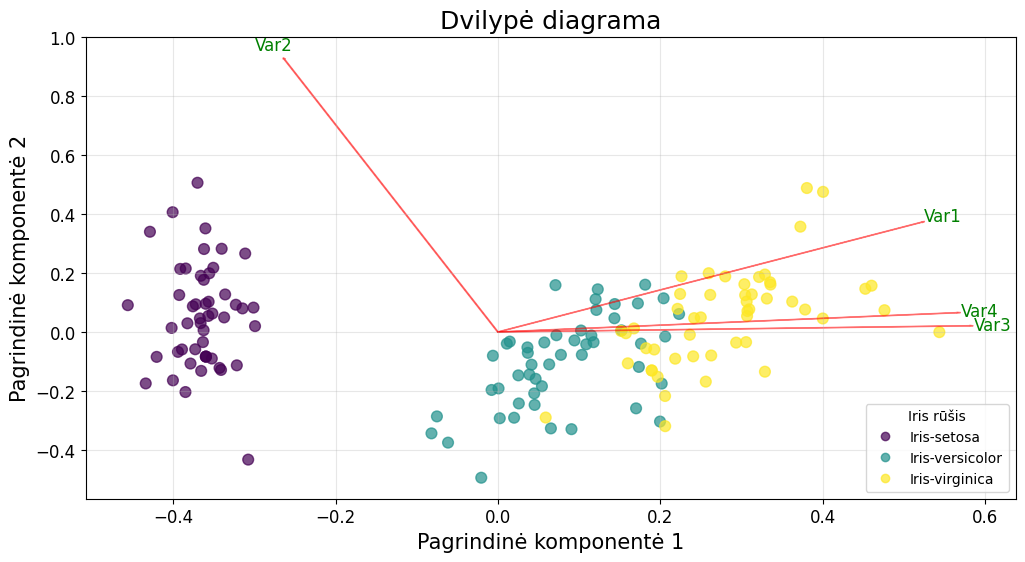

In [24]:
koduotes, target_names = pd.factorize(y_iris)

def biplot(score, coeff, labels=None, c=None, target_names = None):
    xs = score[:,0]
    ys = score[:,1]
    n = coeff.shape[0]
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())
    scatter = plt.scatter(xs * scalex, ys * scaley, s=60, c=c, cmap='viridis', alpha=0.7)
    for i in range(n):
        plt.arrow(0, 0, coeff[i,0], coeff[i,1], color = 'red', alpha = 0.5)
        if labels is None:
            plt.text(coeff[i,0]* 1.05, coeff[i,1] * 1.05, "Var"+str(i+1), color = 'green', fontsize=12, ha = 'center', va = 'center')
        else:
            plt.text(coeff[i,0]* 1.05, coeff[i,1] * 1.05, labels[i], color = 'green', fontsize=12, ha = 'center', va = 'center')
    
    plt.title("Dvilypė diagrama", fontsize=18)
    plt.xlabel("Pagrindinė komponentė {}".format(1), fontsize=15)
    plt.ylabel("Pagrindinė komponentė {}".format(2), fontsize=15)
    plt.tick_params(axis='both', which='major', labelsize=12)
    plt.grid(alpha=0.3)

    if target_names is not None:
        handles, _ = scatter.legend_elements()
        plt.legend(handles, target_names, title="Iris rūšis", loc="lower right", fontsize=10)

plt.figure(figsize=(12, 6))
biplot(data_pca, np.transpose(pca.components_), c = y_numeric, target_names = target_names)


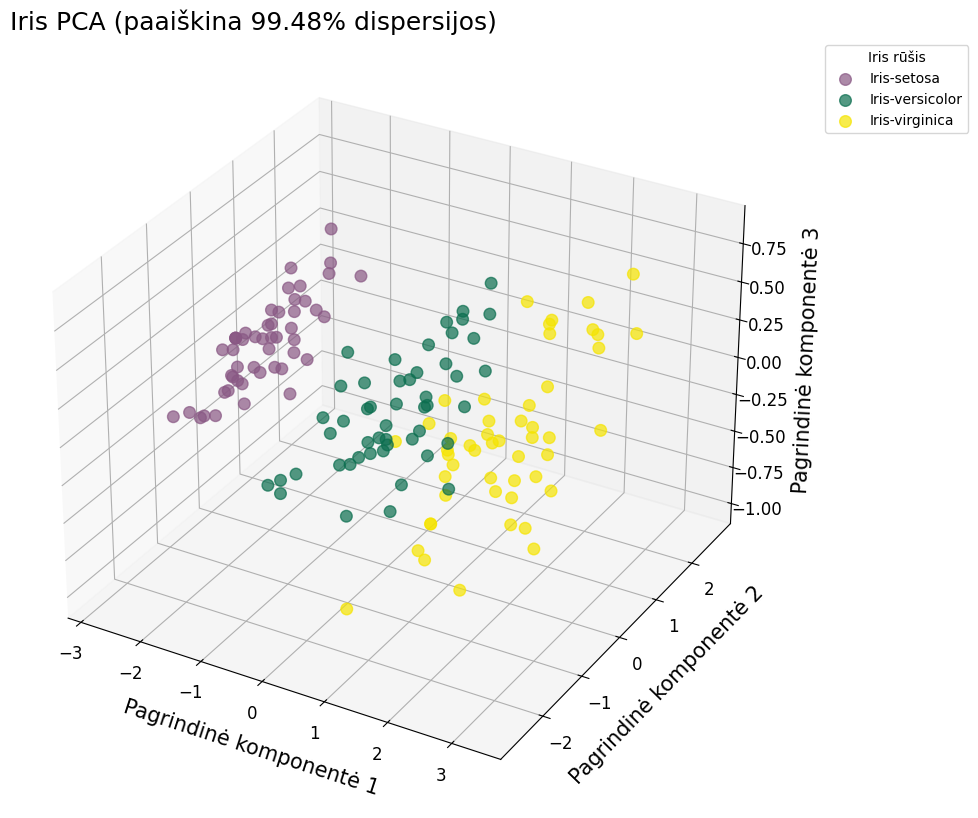

In [25]:
total_explained_variance = sum(pca.explained_variance_ratio_[:3]) * 100
colors = ["#895884", "#0B6E4F", "#F5E400"]

pca_3d_df = pd.DataFrame(data_pca[:, :3], columns=["PC1", "PC2", "PC3"])
pca_3d_df["y"] = y_iris

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection="3d")

for i, target in enumerate(sorted(pca_3d_df["y"].unique())):
    subset = pca_3d_df[pca_3d_df["y"] == target]
    ax.scatter(xs=subset["PC1"], ys=subset["PC2"], zs=subset["PC3"], s=70, alpha=0.7, c=colors[i], edgecolors=colors[i], label=target)

ax.set_xlabel("Pagrindinė komponentė 1", fontsize=15, labelpad=10)
ax.set_ylabel("Pagrindinė komponentė 2", fontsize=15, labelpad=10)
ax.set_zlabel("Pagrindinė komponentė 3", fontsize=15, labelpad=10)
ax.set_title(f"Iris PCA (paaiškina {total_explained_variance:.2f}% dispersijos)", loc="left", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(alpha=0.3)

ax.legend(title="Iris rūšis", loc="upper left", bbox_to_anchor=(1.05, 1))
plt.show()

-----

#### Trečias duomenų rinkinys:

In [26]:
df_train = pd.read_csv("mnist_train.csv", sep = ',')
df_train.head(5)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
y_labels = df_train['label']
df_train = df_train.drop('label', axis=1)

In [28]:
print("Skirtingų grupių skaičius:", len(y_labels.unique()))
print("Duomenų struktūra: ", df_train.shape)

Skirtingų grupių skaičius: 10
Duomenų struktūra:  (60000, 784)


In [29]:
train_scaled = sc.fit_transform(df_train)
transformed_train1, variance_train1 = PCA_Algorithm1(train_scaled)
variance_train1_proc = np.round(variance_train1 * 100, decimals = 1)

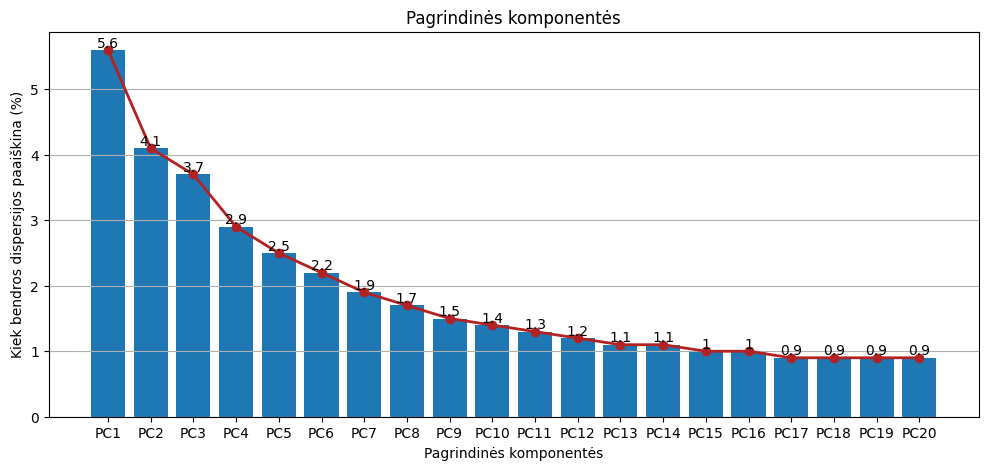

In [30]:
variance_train1_proc_top = variance_train1_proc[:20]
labels = ["PC" + str(x) for x in range(1, len(variance_train1_proc_top) + 1)]

plt.figure(figsize = (12, 5))
plt.grid(axis = 'y')
bars = plt.bar(x = range(1, len(variance_train1_proc_top) + 1), height = variance_train1_proc_top, tick_label = labels)
plt.bar_label(bars)
plt.plot(range(1, len(variance_train1_proc_top) + 1), variance_train1_proc_top, marker = 'o', color='firebrick', linewidth = 2, markersize = 6)
plt.title("Pagrindinės komponentės")
plt.ylabel("Kiek bendros dispersijos paaiškina (%)")
plt.xlabel("Pagrindinės komponentės")
plt.show()

In [31]:
transformed_train3, variance_train3 = PCA_Algorithm3(train_scaled)
variance_train3_proc = np.round(variance_train3 * 100, decimals = 1)

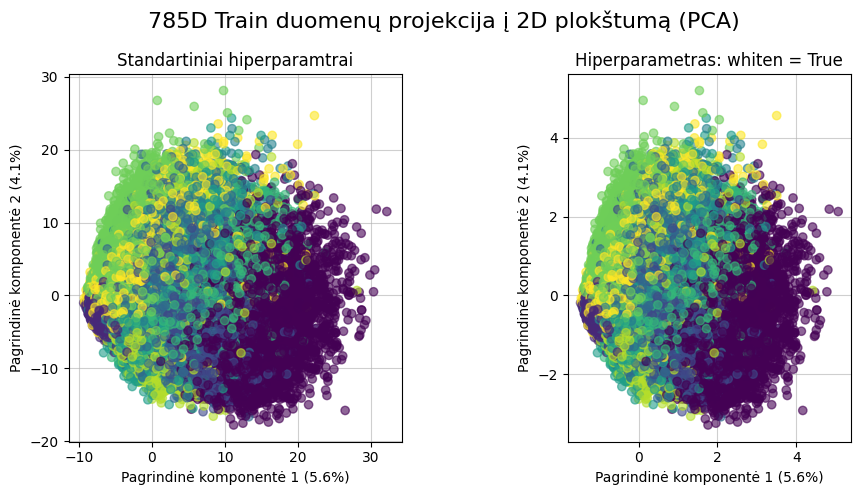

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.scatter(transformed_train1[:, 0], transformed_train1[:, 1], alpha=0.6, c = y_labels)
ax1.set_title("Standartiniai hiperparamtrai")
ax1.set_xlabel(f"Pagrindinė komponentė 1 ({variance_train1_proc[0]}%)")
ax1.set_ylabel(f"Pagrindinė komponentė 2 ({variance_train1_proc[1]}%)")
ax1.grid(alpha=0.6)
ax1.set_aspect('equal', adjustable='box')
ax1.set_axisbelow(True)

ax2.scatter(transformed_train3[:, 0], transformed_train3[:, 1], alpha=0.6, c = y_labels)
ax2.set_title("Hiperparametras: whiten = True")
ax2.set_xlabel(f"Pagrindinė komponentė 1 ({variance_train3_proc[0]}%)")
ax2.set_ylabel(f"Pagrindinė komponentė 2 ({variance_train3_proc[1]}%)")
ax2.grid(alpha=0.6)
ax2.set_aspect('equal', adjustable='box')
ax2.set_axisbelow(True)

plt.suptitle("785D Train duomenų projekcija į 2D plokštumą (PCA)", fontsize=16)
plt.tight_layout()
plt.show()

In [33]:
pca_solvers(train_scaled)

,solver,time (s)
0,auto,1.096442
1,full,5.777763
2,covariance_eigh,1.038699
3,arpack,35.838370
4,randomized,19.585018


-----

#### Ketvirtas duomenų rinkinys:

In [34]:
df_swissroll = pd.read_csv("swiss_roll_example.csv", sep = ';', header = None)
df_swissroll.head(5)

,0,1,2
0,12.2009,8.8806,-2.1622
1,10.2780,1.9788,8.3610
2,5.5008,12.5690,-2.1587
3,9.7068,9.8894,9.1226
4,-3.3909,14.6149,-10.1192


In [35]:
print("Duomenų struktūra: ", df_swissroll.shape)

Duomenų struktūra:  (400, 3)


In [36]:
swissroll_scaled = sc.fit_transform(df_swissroll)
transformed_swissroll1, variance_swissroll1 = PCA_Algorithm1(swissroll_scaled)
variance_swissroll1_proc = np.round(variance_swissroll1 * 100, decimals = 1)

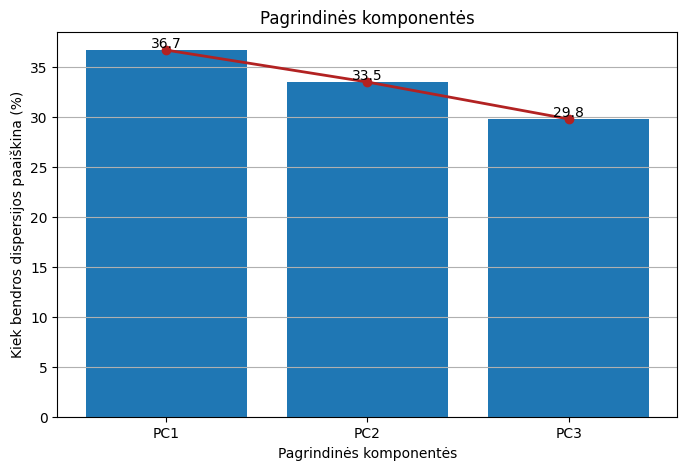

In [37]:
labels = ["PC" + str(x) for x in range(1, len(variance_swissroll1_proc) + 1)]

plt.figure(figsize = (8, 5))
plt.grid(axis = 'y')
bars = plt.bar(x = range(1, len(variance_swissroll1_proc) + 1), height = variance_swissroll1_proc, tick_label = labels)
plt.bar_label(bars)
plt.plot(range(1, len(variance_swissroll1_proc) + 1), variance_swissroll1_proc, marker = 'o', color='firebrick', linewidth = 2, markersize = 6)
plt.title("Pagrindinės komponentės")
plt.ylabel("Kiek bendros dispersijos paaiškina (%)")
plt.xlabel("Pagrindinės komponentės")
plt.show()

In [38]:
transformed_swissroll3, variance_swissroll3 = PCA_Algorithm3(swissroll_scaled)
variance_swissroll3_proc = np.round(variance_swissroll3 * 100, decimals = 1)

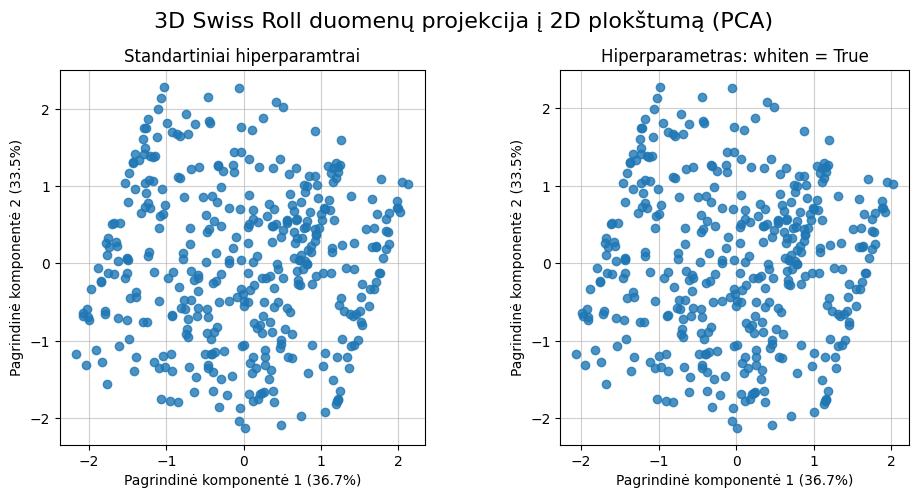

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.scatter(transformed_swissroll1[:, 0], transformed_swissroll1[:, 1], alpha=0.8)
ax1.set_title("Standartiniai hiperparamtrai")
ax1.set_xlabel(f"Pagrindinė komponentė 1 ({variance_swissroll1_proc[0]}%)")
ax1.set_ylabel(f"Pagrindinė komponentė 2 ({variance_swissroll1_proc[1]}%)")
ax1.grid(alpha=0.6)
ax1.set_aspect('equal', adjustable='box')
ax1.set_axisbelow(True)

ax2.scatter(transformed_swissroll3[:, 0], transformed_swissroll3[:, 1], alpha=0.8)
ax2.set_title("Hiperparametras: whiten = True")
ax2.set_xlabel(f"Pagrindinė komponentė 1 ({variance_swissroll3_proc[0]}%)")
ax2.set_ylabel(f"Pagrindinė komponentė 2 ({variance_swissroll3_proc[1]}%)")
ax2.grid(alpha=0.6)
ax2.set_aspect('equal', adjustable='box')
ax2.set_axisbelow(True)

plt.suptitle("3D Swiss Roll duomenų projekcija į 2D plokštumą (PCA)", fontsize=16)
plt.tight_layout()
plt.show()

In [40]:
pca_solvers(swissroll_scaled)

,solver,time (s)
0,auto,0.001399
1,full,0.001008
2,covariance_eigh,0.001555
3,arpack,0.001541
4,randomized,0.003546


### PAC modifikacijos

In [41]:
from sklearn.decomposition import KernelPCA
from sklearn.decomposition import SparsePCA

In [42]:
kernel_pca = KernelPCA(n_components=2, kernel='rbf')
ellipsoid_transformed_KPCA = kernel_pca.fit_transform(df_ellipsoid)

In [43]:
sparce_pca = SparsePCA(n_components=2)
ellipsoid_transformed_SPCA = sparce_pca.fit_transform(df_ellipsoid)

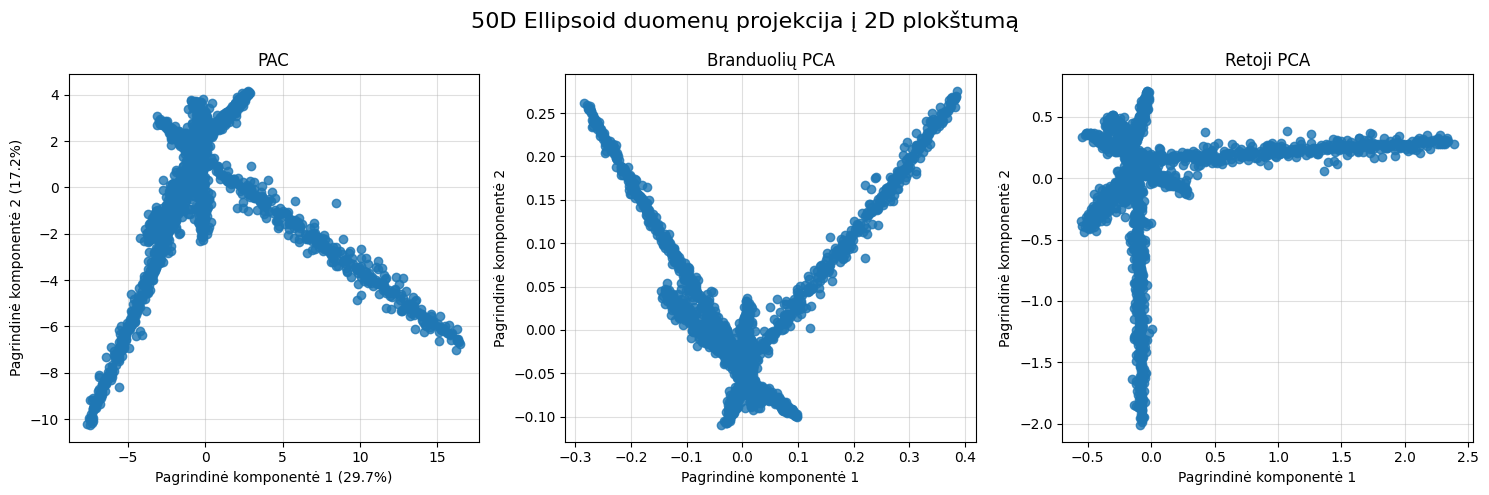

In [49]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,5))

ax1.scatter(transformed_ellipsoid1[:, 0], transformed_ellipsoid1[:, 1], alpha=0.8)
ax1.set_title("PAC")
ax1.set_xlabel(f"Pagrindinė komponentė 1 ({variance_ellipsoid1_proc[0]}%)")
ax1.set_ylabel(f"Pagrindinė komponentė 2 ({variance_ellipsoid1_proc[1]}%)")
ax1.grid(alpha=0.4)
ax1.set_axisbelow(True)

ax2.scatter(ellipsoid_transformed_KPCA[:, 0], ellipsoid_transformed_KPCA[:, 1], alpha=0.8)
ax2.set_title("Branduolių PCA")
ax2.set_xlabel(f"Pagrindinė komponentė 1")
ax2.set_ylabel(f"Pagrindinė komponentė 2")
ax2.grid(alpha=0.4)
ax2.set_axisbelow(True)

ax3.scatter(ellipsoid_transformed_SPCA[:, 0], ellipsoid_transformed_SPCA[:, 1], alpha=0.8)
ax3.set_title("Retoji PCA")
ax3.set_xlabel(f"Pagrindinė komponentė 1")
ax3.set_ylabel(f"Pagrindinė komponentė 2")
ax3.grid(alpha=0.4)
ax3.set_axisbelow(True)

plt.suptitle("50D Ellipsoid duomenų projekcija į 2D plokštumą", fontsize=16)
plt.tight_layout()
plt.show()

In [45]:
swissroll_transformed_KPCA = kernel_pca.fit_transform(df_swissroll)

In [48]:
swissroll_transformed_SPCA = sparce_pca.fit_transform(df_swissroll)
sparce_pca.components_

array([[ 0.        ,  0.14992599,  0.98869722],
       [ 0.99851551, -0.0544681 ,  0.        ]])

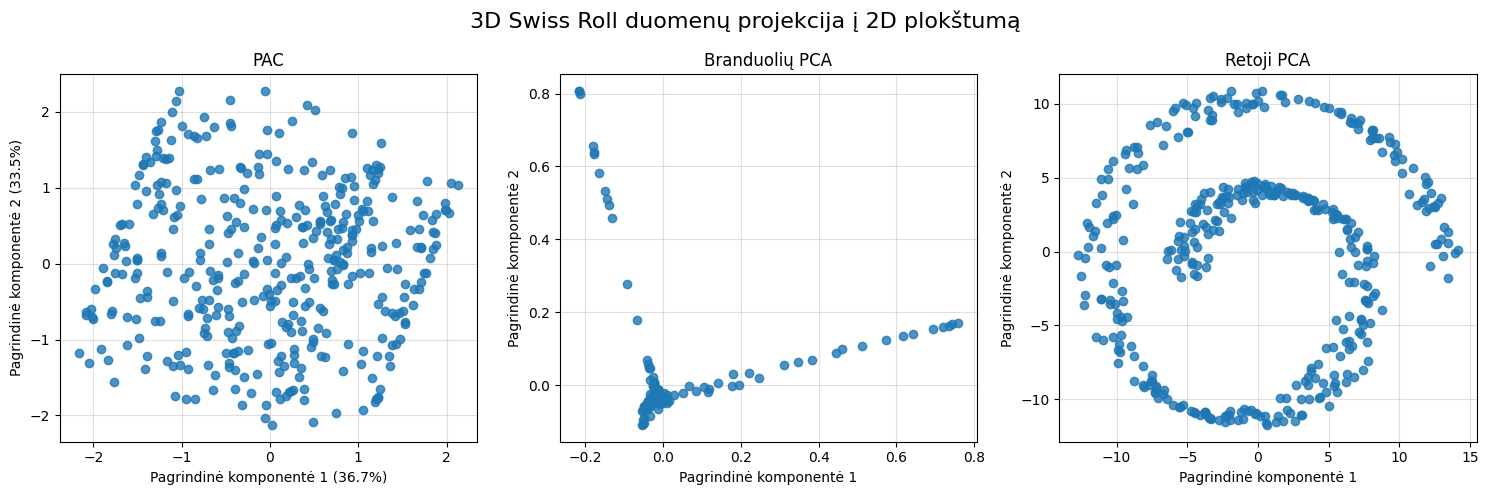

In [47]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,5))

ax1.scatter(transformed_swissroll1[:, 0], transformed_swissroll1[:, 1], alpha=0.8)
ax1.set_title("PAC")
ax1.set_xlabel(f"Pagrindinė komponentė 1 ({variance_swissroll1_proc[0]}%)")
ax1.set_ylabel(f"Pagrindinė komponentė 2 ({variance_swissroll1_proc[1]}%)")
ax1.grid(alpha=0.4)
ax1.set_axisbelow(True)

ax2.scatter(swissroll_transformed_KPCA[:, 0], swissroll_transformed_KPCA[:, 1], alpha=0.8)
ax2.set_title("Branduolių PCA")
ax2.set_xlabel(f"Pagrindinė komponentė 1")
ax2.set_ylabel(f"Pagrindinė komponentė 2")
ax2.grid(alpha=0.4)
ax2.set_axisbelow(True)

ax3.scatter(swissroll_transformed_SPCA[:, 0], swissroll_transformed_SPCA[:, 1], alpha=0.8)
ax3.set_title("Retoji PCA")
ax3.set_xlabel(f"Pagrindinė komponentė 1")
ax3.set_ylabel(f"Pagrindinė komponentė 2")
ax3.grid(alpha=0.4)
ax3.set_axisbelow(True)

plt.suptitle("3D Swiss Roll duomenų projekcija į 2D plokštumą", fontsize=16)
plt.tight_layout()
plt.show()

-----

Šaltiniai:
- https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
- https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.KernelPCA.html
- https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.SparsePCA.html
- https://towardsdatascience.com/5-pca-visualizations-you-must-try-on-your-next-data-science-project-148ec3d31e4d/